In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import sys
import os
import pickle
from tqdm import tqdm
# Get the absolute path to the folder containing `utils`
utils_path = os.path.abspath('../')
if utils_path not in sys.path:
    sys.path.append(utils_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "1" # second gpu
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

from utils import *

# az.style.use("arviz-docgrid")
plt.rcParams['figure.dpi'] = 140

experiment_orientations = [159, 123, 87, 51, 15]
subjects = ["01", "02", "03", "04", "05", "06", "07" ,"09", "10", "11", "12"]
median_key = {15:0, 51:1, 87:2, 123:3, 159:4}
std_key = {15:0, 51:1, 87:2, 123:3, 159:4}

c_table = pd.read_csv('../data_caches/ctiraltable.csv')
med = np.load('../data_caches/med.npy')
std = np.load('../data_caches/std.npy')
ctimetable = np.load('../data_caches/ctimetable.npy')
r_table = pd.read_csv('../data_caches/rtrialtable.csv', index_col=0)
(x, y, d, r, e, cd, ce) = np.load('../data_caches/rtimetable.npy', allow_pickle=True)

In [2]:
import jax
jax.config.update('jax_platform_name', 'gpu')

import jax.numpy as jnp
import jax.random as jr
from jax import lax
from jax import vmap
import optax

from jax.extend import backend
print(backend.get_backend().platform)

gpu


In [3]:
def train_hmm(model, emissions, inputs, verbose = True):
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions, inputs = inputs, num_iters = 10,verbose = verbose)
    return model, fit_params, lps

## Data

In [4]:
# Data Prepping

# copy r_table completely to keep backup
rdf = r_table.copy()

# Add 2 more columns,
# - target at previous trial
# - response at previous trial

rdf['prev_target'] = rdf.groupby(['subj', 'sess', 'run'])['t_calib'].shift(1)
rdf['prev_resp']   = rdf.groupby(['subj', 'sess', 'run'])['resp'].shift(1)

# Replace NaN values in the first trial of each group with the current trial's value
rdf['prev_target'] = rdf['prev_target'].fillna(rdf['t_calib'])
rdf['prev_resp']   = rdf['prev_resp'].fillna(rdf['resp'])

rdf.head()


,subj,sess,run,trial,target,t_calib,resp,resp_err,v_err,exp,...,2sig,nn_c,att,coh,exp_al,f_onset,f_resp,dir,prev_target,prev_resp
0,1,0,0,0,159.0,145.788047,148.685925,2.897877,2.897877,145.788047,...,1.0,1.0,divided,high,expected,132,373,higher,145.788047,148.685925
1,1,0,0,1,123.0,136.060195,129.253756,6.806439,-6.806439,145.788047,...,1.0,1.0,focused,high,unexpected,204,280,lower,145.788047,148.685925
2,1,0,0,2,51.0,33.954344,124.965094,91.010750,91.010750,145.788047,...,0.0,0.0,focused,high,unexpected,168,250,higher,136.060195,129.253756
3,1,0,0,3,159.0,145.788047,145.702460,0.085587,-0.085587,145.788047,...,1.0,1.0,divided,high,expected,168,337,lower,33.954344,124.965094
4,1,0,0,4,15.0,18.896223,144.334808,125.438585,125.438585,145.788047,...,0.0,0.0,divided,low,unexpected,180,270,higher,145.788047,145.702460


In [5]:
# Modeling setup:
# - emissions : resp
# - inputs : t_calib, prev_target, prev_resp

# Training a global model - use all data combined
ems = jnp.array(np.deg2rad(rdf['resp'].values.reshape(-1, 120,1)))
ins = jnp.array(np.deg2rad(rdf[['t_calib', 'prev_target', 'prev_resp']].values.reshape(-1, 120,3)))

ems.shape, ins.shape

((288, 120, 1), (288, 120, 3))

In [32]:
# emissions = ems[:, 0:40, :]
# inputs = ins[:, 0:40, :]

# emissions = ems[:, 40:80, :]
# inputs = ins[:, 40:80, :]

emissions = ems[:, 80:120, :]
inputs = ins[:, 80:120, :]

In [33]:
num_states, input_dim, emission_dim = 2, 3, 1

with open('./caches/global_params.pkl', 'rb') as f:
    global_params = pickle.load(f)
    
    
crossval_results = {}

for idx, (s_em, s_in) in enumerate(zip(emissions.reshape(12, 4 * 6, 40, 1)[8:9, :, :], inputs.reshape(12, 4 * 6, 40, 3)[8:9, :, :])):
    crossval_results[idx] = {}
    shuffle_idx = np.random.permutation(len(s_em))
    
    for nstate in tqdm(range(2, 10), desc=f'sub-{idx+1}'):
        model = CircularRegressionHMM(nstate, input_dim, emission_dim)
        gpar = global_params[nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                  method="prior",
                                                  initial_probs=gpar.initial.probs,
                                                  transition_matrix=gpar.transitions.transition_matrix,
                                                  emission_weights=gpar.emissions.weights,
                                                  emission_biases=gpar.emissions.biases,
                                                  emission_covariances=gpar.emissions.covs,)
        ll_mean, ll = cross_validate_regressor(model=model, emissions=s_em[shuffle_idx], key=jr.PRNGKey(0), num_iters=100, inputs=s_in[shuffle_idx], init = (parameters, properties))
        crossval_results[idx][nstate] = ll
        
subject_params = {}

for idx, (s_em, s_in) in enumerate(zip(emissions.reshape(12, 4 * 6, 40, 1)[8:9, :, :], inputs.reshape(12, 4 * 6, 40, 3)[8:9, :, :])):
    subject_params[idx] = {}
    shuffle_idx = np.random.permutation(len(s_em))
    
    nstate = 2
    model = CircularRegressionHMM(nstate, input_dim, emission_dim)
    gpar = global_params[nstate]
    parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                method="prior",
                                                initial_probs=gpar.initial.probs,
                                                transition_matrix=gpar.transitions.transition_matrix,
                                                emission_weights=gpar.emissions.weights,
                                                emission_biases=gpar.emissions.biases,
                                                emission_covariances=gpar.emissions.covs,)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = s_em[shuffle_idx], inputs = s_in[shuffle_idx], num_iters = 100, verbose = False)
    
    subject_params[idx][nstate] = fit_params

sub-1:   0%|          | 0/8 [00:00<?, ?it/s]

sub-1: 100%|██████████| 8/8 [01:17<00:00,  9.64s/it]


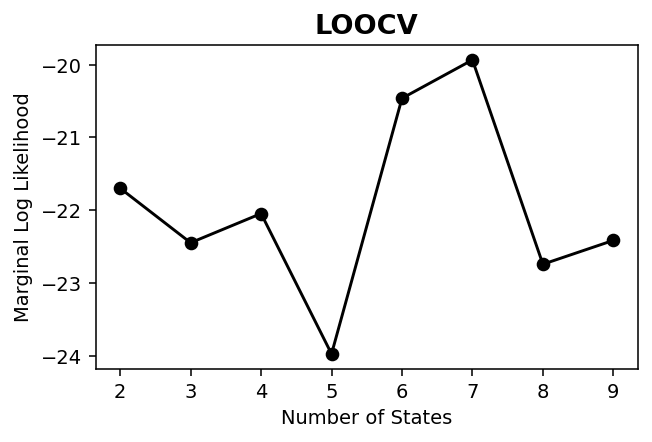

In [37]:
full_crossval = crossval_results.copy()

# Lets take a look at the cross validated log likelihoods
plt.figure(figsize=(5, 3))
# marginal likelihoods in y axis
plt.plot(np.arange(8), [np.mean([full_crossval[0][j]]) for j in range(2, 10)], marker='o', label='Mean', color='black')
plt.xticks(np.arange(8), np.arange(2, 10))
plt.xlabel('Number of States')
plt.ylabel('Marginal Log Likelihood')
plt.title('LOOCV', fontsize=14, weight='bold')
plt.show()

In [38]:
weights = []
biases = []
transitions = []
covs = []

for i in range(1):
    weights.append(subject_params[i][2].emissions.weights)
    biases.append(subject_params[i][2].emissions.biases)
    transitions.append(subject_params[i][2].transitions.transition_matrix)
    covs.append(subject_params[i][2].emissions.covs)

weights = np.array(weights)
biases = np.array(biases)
transitions = np.array(transitions)
covs = np.array(covs)

weights = weights.transpose(0,1,3,2).reshape(1, 2, 3)
biases = biases.reshape(1, 2)
transitions = transitions.reshape(1, 2, 2)
covs = covs.reshape(1, 2)

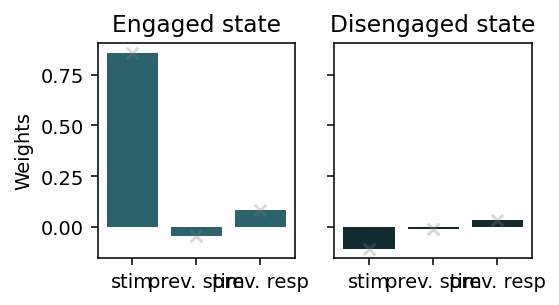

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(4, 2), sharex=True, sharey=True)

# Sns barplot the (12, 2, 3) weights with 12 dots in each and 2 for the 2 plots and 3 for the bars

sns.barplot(x=["stim", "prev. stim", "prev. resp"], y=weights.mean(axis=0)[0], ax=ax[0], color="#216976")
sns.barplot(x=["stim", "prev. stim", "prev. resp"], y=weights.mean(axis=0)[1], ax=ax[1], color="#0e2d33")

# title them engaged and disengaged
ax[0].set_title("Engaged state")
ax[1].set_title("Disengaged state")

# Show the dots for each subject
for i in range(1):
    ax[0].scatter(["stim", "prev. stim", "prev. resp"], weights[i][0], color="gray", alpha=0.3, marker="x")
    ax[1].scatter(["stim", "prev. stim", "prev. resp"], weights[i][1], color="gray", alpha=0.3, marker="x")
    
ax[0].set_ylabel("Weights")
# plt.show()
plt.savefig("weights.svg", format="svg", transparent=True)

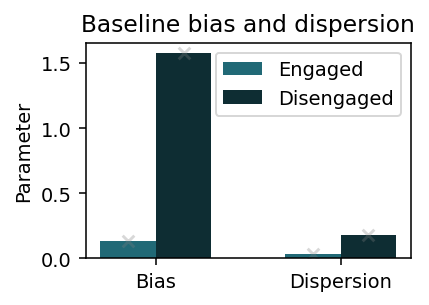

In [36]:
# Define group centers for Bias and Cov on the x-axis.
x_groups = np.array([0, 1])  # 0: Bias, 1: Cov
offset = 0.15  # horizontal offset for the two states

# Set x positions for the two states within each group.
# For Bias: Engaged will be left, Disengaged right.
x_bias_engaged = x_groups[0] - offset
x_bias_disengaged = x_groups[0] + offset
# For Cov: Engaged left, Disengaged right.
x_cov_engaged = x_groups[1] - offset
x_cov_disengaged = x_groups[1] + offset

# Compute mean values for each.
bias_mean = biases.mean(axis=0)  # [Engaged, Disengaged]
cov_mean = covs.mean(axis=0)      # [Engaged, Disengaged]

fig, ax = plt.subplots(figsize=(3,2))

# Plot bars for Bias.
ax.bar(x_bias_engaged, bias_mean[0], width=0.3, color="#216976", label="Engaged")
ax.bar(x_bias_disengaged, bias_mean[1], width=0.3, color="#0e2d33", label="Disengaged")

# Plot bars for Cov.
ax.bar(x_cov_engaged, cov_mean[0], width=0.3, color="#216976")
ax.bar(x_cov_disengaged, cov_mean[1], width=0.3, color="#0e2d33")

# Overlay individual subject data.
for i in range(biases.shape[0]):
    # For Bias.
    ax.scatter(x_bias_engaged, biases[i, 0], color="gray", alpha=0.3, marker="x")
    ax.scatter(x_bias_disengaged, biases[i, 1], color="gray", alpha=0.3, marker="x")
    # For Cov.
    ax.scatter(x_cov_engaged, covs[i, 0], color="gray", alpha=0.3, marker="x")
    ax.scatter(x_cov_disengaged, covs[i, 1], color="gray", alpha=0.3, marker="x")

# Set x-axis ticks and labels for the two groups.
ax.set_xticks(x_groups)
ax.set_xticklabels(["Bias", "Dispersion"])
ax.set_ylabel("Parameter")
ax.set_title("Baseline bias and dispersion")
ax.legend()
# plt.show()
plt.savefig("bias.svg", format="svg", transparent=True)


## Global initializer

In [6]:
num_states, input_dim, emission_dim = 2, 3, 1

In [ ]:
global_params = {}

for nstate in tqdm(range(2, 10)):
    model = CircularRegressionHMM(nstate, input_dim, emission_dim)
    parameters, properties = model.initialize(key=jr.PRNGKey(1), method="prior", emissions = emissions)
    subset_idx = np.random.choice(np.arange(0, len(emissions)), len(emissions), replace=False)
    fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = emissions[subset_idx], inputs = inputs[subset_idx], num_iters = 100, verbose = False)
    global_params[nstate] = fit_params

In [ ]:
# with open('./caches/global_params.pkl', 'wb') as f:
#     pickle.dump(global_params, f)
    
# with open('./caches/global_params.pkl', 'rb') as f:
#     global_params = pickle.load(f)

In [7]:
# num_states, input_dim, emission_dim = 2, 3, 1
# global_crossval = {}

# for nstate in tqdm(range(2, 10)):
#     model = CircularRegressionHMM(nstate, input_dim, emission_dim)
#     # make index of emissions size and shufflei t
#     shuffled_indices = np.random.permutation(emissions.shape[0])
#     parameters, properties = model.initialize(key=jr.PRNGKey(nstate), method="kmeans", emissions = emissions[shuffled_indices])
#     ll_mean, ll = cross_validate_regressor(model=model, emissions=emissions[shuffled_indices], key=jr.PRNGKey(0), num_iters=100, inputs=inputs[shuffled_indices])
#     global_crossval[nstate] = ll

In [ ]:
# with open('./caches/global_crossval.pkl', 'wb') as f:
#     pickle.dump(global_crossval, f)
    
# with open('./caches/global_crossval.pkl', 'rb') as f:
#     global_crossval = pickle.load(f)

## Crossvalidate subject models LOO

In [ ]:
# with open('./caches/sub_crossval_results.pkl', 'wb') as f:
#     pickle.dump(crossval_results, f)
# with open('./caches/sub_crossval_results.pkl', 'rb') as f:
#     crossval_results = pickle.load(f)

## Subject models

Therefore according to the cross val, it suggests x states so now we full train on those x states

In [ ]:
# subject_params = {}

# for idx, (s_em, s_in) in enumerate(zip(emissions.reshape(12, 4 * 6, 120, 1), inputs.reshape(12, 4 * 6, 120, 3))):
#     subject_params[idx] = {}
#     shuffle_idx = np.random.permutation(len(s_em))
    
#     nstate = 2
#     model = CircularRegressionHMM(nstate, input_dim, emission_dim)
#     gpar = global_params[nstate]
#     parameters, properties = model.initialize(key=jr.PRNGKey(1), 
#                                                 method="prior",
#                                                 initial_probs=gpar.initial.probs,
#                                                 transition_matrix=gpar.transitions.transition_matrix,
#                                                 emission_weights=gpar.emissions.weights,
#                                                 emission_biases=gpar.emissions.biases,
#                                                 emission_covariances=gpar.emissions.covs,)
#     fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = s_em[shuffle_idx], inputs = s_in[shuffle_idx], num_iters = 100, verbose = False)
    
#     subject_params[idx][nstate] = fit_params

In [ ]:
# with open('./caches/subject_params.pkl', 'wb') as f:
#     pickle.dump(subject_params, f)
    
# with open('./caches/subject_params.pkl', 'rb') as f:
#     subject_params = pickle.load(f)

## Condition fits

In [15]:
emissions.shape

(288, 120, 1)

In [16]:
# expected data 
expected_em = emissions.reshape(12, 4, 6, 120, 1)[:,:,:5,:,:]
expected_in = inputs.reshape(12, 4, 6, 120, 3)[:,:,:5,:,:]

unexpected_em = emissions.reshape(12, 4, 6, 120, 1)[:,:,5:,:,:]
unexpected_in = inputs.reshape(12, 4, 6, 120, 3)[:,:,5:,:,:]

expected_em.shape, expected_in.shape, unexpected_em.shape, unexpected_in.shape

((12, 4, 5, 120, 1),
 (12, 4, 5, 120, 3),
 (12, 4, 1, 120, 1),
 (12, 4, 1, 120, 3))

In [17]:
# cond_params = {}
# nstate = 2

# names = ["unexpected", "expected"]

# for (cem, cin), name in zip(((unexpected_em, unexpected_in), (expected_em, expected_in)), names):
#     cond_params[name] = {}
    
#     for idx in tqdm(range(12), desc=f'{name}'):
        
#         em = jnp.array(cem[idx].reshape(-1, 120, 1))
#         inps = jnp.array(cin[idx].reshape(-1, 120, 3))
#         shuffle_idx = np.random.permutation(len(em))
#         model = CircularRegressionHMM(nstate, input_dim, emission_dim)
        
#         gpar = subject_params[idx][nstate]
#         parameters, properties = model.initialize(key=jr.PRNGKey(1), 
#                                                     method="prior",
#                                                     initial_probs=gpar.initial.probs,
#                                                     transition_matrix=gpar.transitions.transition_matrix,
#                                                     emission_weights=gpar.emissions.weights,
#                                                     emission_biases=gpar.emissions.biases,
#                                                     emission_covariances=gpar.emissions.covs,)
#         fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = em[shuffle_idx], inputs = inps[shuffle_idx], num_iters = 100, verbose = False)
        
#         cond_params[name][idx] = fit_params

In [18]:
# with open('./caches/cond_params.pkl', 'wb') as f:
#     pickle.dump(cond_params, f)
    
with open('./caches/cond_params.pkl', 'rb') as f:
    cond_params = pickle.load(f)

# ML STATE

In [19]:
ml_states = {}
nstate = 2

names = ["unexpected", "expected"]

for (cem, cin), name in zip(((unexpected_em, unexpected_in), (expected_em, expected_in)), names):
    ml_states[name] = {}
    
    for idx in tqdm(range(12), desc=f'{name}'):
        
        shuffle_idx = np.random.permutation(len(cem[idx].reshape(-1, 120, 1)))
        em = jnp.array(cem[idx].reshape(-1, 120, 1)[shuffle_idx])
        inps = jnp.array(cin[idx].reshape(-1, 120, 3)[shuffle_idx])
        model = CircularRegressionHMM(nstate, input_dim, emission_dim)
        
        gpar = subject_params[idx][nstate]
        parameters, properties = model.initialize(key=jr.PRNGKey(1), 
                                                    method="prior",
                                                    initial_probs=gpar.initial.probs,
                                                    transition_matrix=gpar.transitions.transition_matrix,
                                                    emission_weights=gpar.emissions.weights,
                                                    emission_biases=gpar.emissions.biases,
                                                    emission_covariances=gpar.emissions.covs,)
        # fit_params, lps = model.fit_em(params = parameters, props = properties, emissions = em[shuffle_idx], inputs = inps[shuffle_idx], num_iters = 100, verbose = False)
        # Define a vmapped version of most_likely_states.
        # This applies the function to each trial in the batch dimension of `em`.
        most_likely_states_vmap = vmap(lambda trial, inp: model.most_likely_states(parameters, trial, inp))
        t_trail = most_likely_states_vmap(em, inps)
        ml_states[name][idx] = t_trail

expected: 100%|██████████| 12/12 [00:00<00:00, 14.10it/s]


In [ ]:
# with open('./caches/ml_states.pkl', 'wb') as f:
#     pickle.dump(ml_states, f)
    
# with open('./caches/ml_states.pkl', 'rb') as f:
#     ml_states = pickle.load(f)